# Most Frequent Imputation

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [48]:
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
945,NaN,TA,124900
1369,TA,TA,232000
1362,Gd,TA,104900
147,Gd,TA,222500
286,Gd,TA,159000


In [49]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

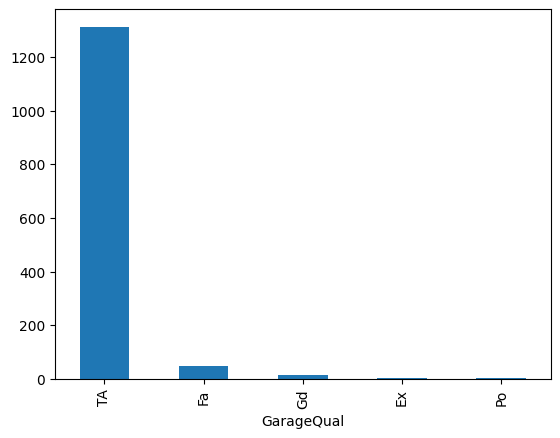

In [50]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()

In [51]:
df['GarageQual'].mode()

,GarageQual
0,TA


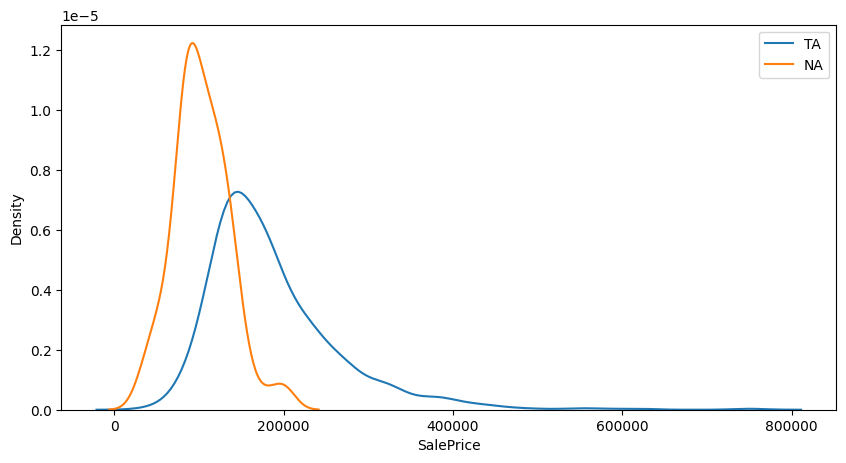

In [52]:
fig = plt.figure(figsize=(10,5))
sns.kdeplot(df[df['GarageQual']=='TA']['SalePrice'],label='TA')
# sns.kdeplot(df[df['GarageQual']=='Gd']['SalePrice'],label='Gd')
# sns.kdeplot(df[df['GarageQual']=='Ex']['SalePrice'],label='Ex')
# sns.kdeplot(df[df['GarageQual']=='Fa']['SalePrice'],label='Fa')
# sns.kdeplot(df[df['GarageQual']=='Po']['SalePrice'],label='Po')
sns.kdeplot(df[df['GarageQual'].isnull()]['SalePrice'],label='NA')
plt.legend()

In [53]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [54]:
df['GarageQual'].fillna('TA',inplace=True)

<Axes: xlabel='GarageQual'>

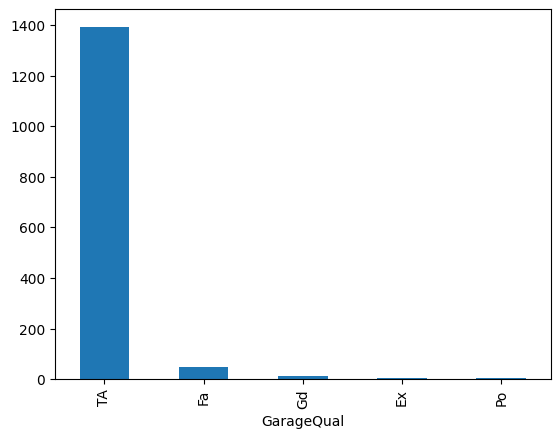

In [55]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

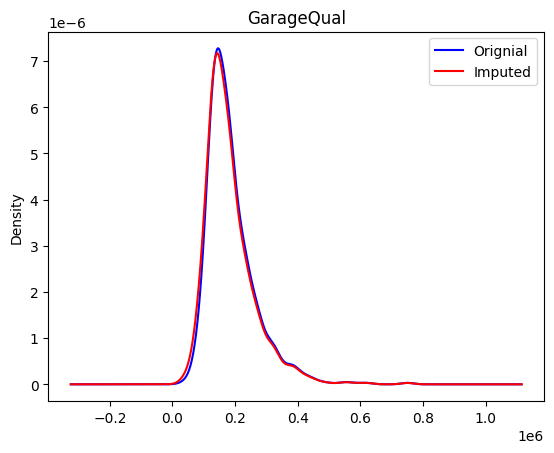

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, color='blue')
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Orignial','Imputed']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

# Green Flag

<Axes: xlabel='FireplaceQu'>

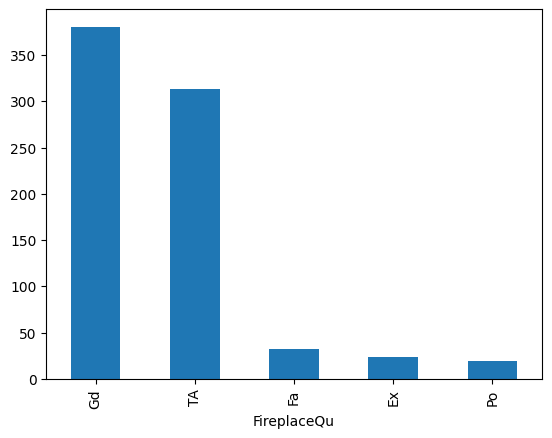

In [57]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [59]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


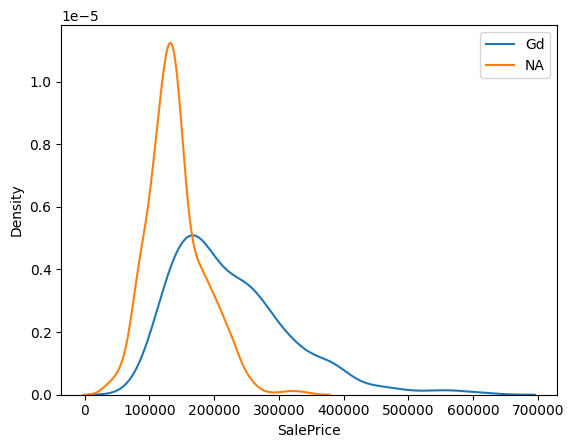

In [62]:
sns.kdeplot(df[df['FireplaceQu']=='Gd']['SalePrice'],label='Gd')
# sns.kdeplot(df[df['FireplaceQu']=='TA']['SalePrice'],label='TA')
# sns.kdeplot(df[df['FireplaceQu']=='Fa']['SalePrice'],label='Fa')
sns.kdeplot(df[df['FireplaceQu'].isnull()]['SalePrice'],label='NA')
plt.legend()

In [63]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [64]:
df['FireplaceQu'].fillna('Gd',inplace=True)

<Axes: xlabel='FireplaceQu'>

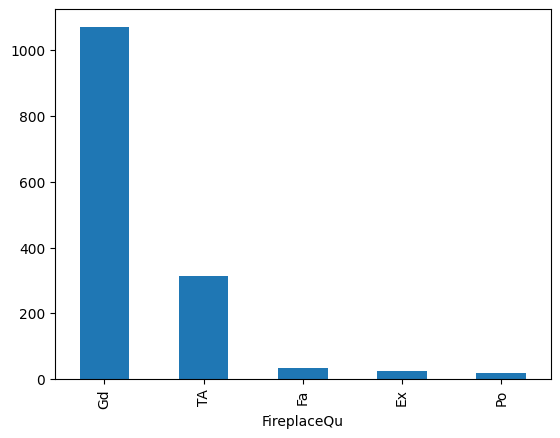

In [65]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

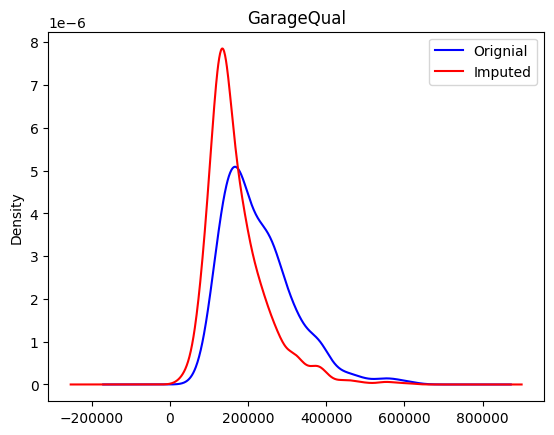

In [69]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, color='blue')
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Orignial','Imputed']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

# Red Flag

# Most Frequent Imputation (Sklearn)

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [71]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [72]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('SalePrice',axis=1),df['SalePrice'],test_size=0.3,random_state=0)

In [73]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [74]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [75]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# Missing Category Imputation

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [77]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [78]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [79]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

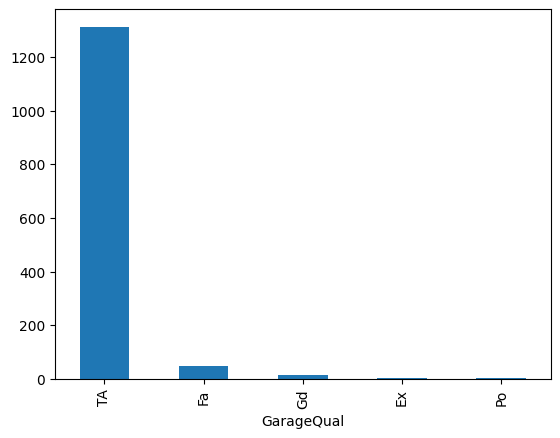

In [80]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()

In [81]:
df['GarageQual'].fillna('Missing',inplace=True)

<Axes: xlabel='GarageQual'>

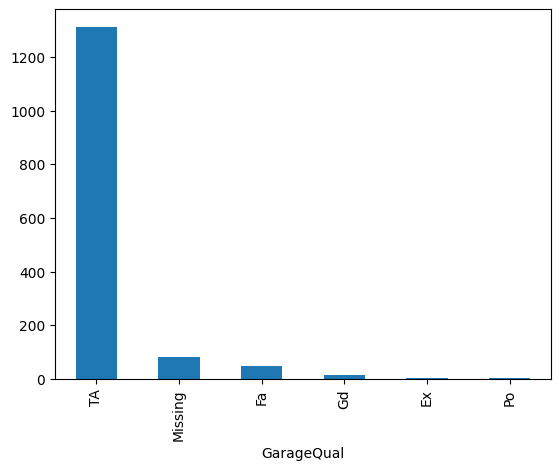

In [82]:
df['GarageQual'].value_counts().plot.bar()

# Missing Category Imputation (Sklearn)

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('SalePrice',axis=1),df['SalePrice'], test_size=0.3,random_state=0)

In [85]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

In [86]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [87]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)